<a href="https://colab.research.google.com/github/AtchayaChandran/Social-Media-Engagement-Analytics/blob/main/Social_Media_Engagement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


In [29]:
#----------Load the CSV File----------
df = pd.read_csv("social_media_engagement_5000.csv")

#----------Display First 5 Rows----------
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [49]:
#----------Check Data Types----------
df.dtypes

#----------Convert posted_at to datetime----------
df["posted_at"] = pd.to_datetime(df["posted_at"], dayfirst=True)

#----------Verify Data Types----------
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [48]:
#----------Check Missing Values----------
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [47]:
#----------Handle Missing Values----------

# Fill numerical columns with median
df["age"] = df["age"].fillna(df["age"].median())
df["likes"] = df["likes"].fillna(df["likes"].median())
df["comments"] = df["comments"].fillna(df["comments"].median())
df["shares"] = df["shares"].fillna(df["shares"].median())
df["watch_time_sec"] = df["watch_time_sec"].fillna(df["watch_time_sec"].median())
df["impression_count"] = df["impression_count"].fillna(df["impression_count"].median())
df["follower_count"] = df["follower_count"].fillna(df["follower_count"].median())
df["engagement_rate"] = df["engagement_rate"].fillna(df["engagement_rate"].median())

# Fill categorical columns with mode
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["country"] = df["country"].fillna(df["country"].mode()[0])
df["post_type"] = df["post_type"].fillna(df["post_type"].mode()[0])
df["post_category"] = df["post_category"].fillna(df["post_category"].mode()[0])
df["device_type"] = df["device_type"].fillna(df["device_type"].mode()[0])
df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode()[0])
df["hashtags"] = df["hashtags"].fillna(df["hashtags"].mode()[0])

# Remove any remaining missing values
df = df.dropna()

#----------Verify Missing Values----------
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [8]:
#----------Check Duplicate Rows----------
print("Duplicate Rows:", df.duplicated().sum())

#----------Remove Duplicate Rows----------
df = df.drop_duplicates()

#----------Verify Duplicate Rows----------
print("Duplicate Rows After Removal:", df.duplicated().sum())

Duplicate Rows: 0
Duplicate Rows After Removal: 0


In [35]:
#----------Standardize Text Columns----------

df["gender"] = df["gender"].str.title()
df["country"] = df["country"].str.title()
df["post_type"] = df["post_type"].str.lower()
df["post_category"] = df["post_category"].str.lower()
df["device_type"] = df["device_type"].str.lower()
df["sentiment"] = df["sentiment"].str.lower()

#----------Correct Unrealistic Values----------

df.loc[df["likes"] < 0, "likes"] = 0
df.loc[df["comments"] < 0, "comments"] = 0
df.loc[df["shares"] < 0, "shares"] = 0

#----------Display First 5 Rows----------
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,Uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,Uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372


In [36]:
#----------Create Hashtag Count----------

df["hashtag_count"] = df["hashtags"].str.count("#")

#----------Clean Sentiment Labels----------

df["sentiment"] = df["sentiment"].str.strip().str.lower()

#----------Display Updated Columns----------
df[["hashtags", "hashtag_count", "sentiment"]].head()

,hashtags,hashtag_count,sentiment
0,#foodie #travel #love,3,negative
1,#fitness,1,negative
2,#foodie,1,positive
3,#music #foodie #fun,3,negative
4,#travel,1,negative


In [46]:
#----------Display First 5 Rows----------
display(df.head())

#----------Display Last 5 Rows----------
display(df.tail())

#----------Display Dataset Shape----------
print("Dataset Shape:")
display(pd.DataFrame({"Rows": [df.shape[0]], "Columns": [df.shape[1]]}))

#----------Display Column Names----------
print("Columns:")
display(df.columns.to_frame(name="Column Name"))

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,Uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,Uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,Uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,Usa,273595,text,travel,13487.0,NaN,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


Dataset Shape:


,Rows,Columns
0,5000,20


Columns:


,Column Name
user_id,user_id
age,age
gender,gender
country,country
post_id,post_id
post_type,post_type
post_category,post_category
likes,likes
comments,comments
shares,shares


In [51]:
#----------Dataset Information----------
df.info

#----------Data Types----------
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [42]:
#----------Summary Statistics----------
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [52]:
#----------Display First 5 Rows----------
df.head()

#----------Display Last 5 Rows----------
df.tail()

#----------Display Dataset Shape----------
print("Dataset Shape:")
df.shape

#----------Display Column Names----------
print("Columns:")
df.columns.to_frame(name="Column Name")

Dataset Shape:
Columns:


,Column Name
user_id,user_id
age,age
gender,gender
country,country
post_id,post_id
post_type,post_type
post_category,post_category
likes,likes
comments,comments
shares,shares


In [53]:
#----------Correlation Matrix----------

correlation_matrix = df.select_dtypes(include=["number"]).corr()

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


In [64]:
#----------Average Likes by Post Type----------
avg_likes = df.groupby("post_type")["likes"].mean()

print("Average Likes by Post Type:")
display(avg_likes.to_frame(name="Average Likes"))

#----------Average Impression Count by Country----------
avg_impressions = df.groupby("country")["impression_count"].mean()

print("\nAverage Impression Count by Country:")
display(avg_impressions.to_frame(name="Average Impression Count"))

Average Likes by Post Type:


,Average Likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000



Average Impression Count by Country:


,Average Impression Count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
Uae,48928.413519
Uk,51119.393509


In [65]:
#----------Create Engagement Score----------

df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)

df[["likes", "comments", "shares", "engagement_score"]].head()

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


In [66]:
#----------Create Time-Based Columns----------

df["month"] = df["posted_at"].dt.month
df["day"] = df["posted_at"].dt.day
df["hour"] = df["posted_at"].dt.hour

df[["posted_at", "month", "day", "hour"]].head()

,posted_at,month,day,hour
0,2022-12-17,12,17,0
1,2023-06-02,6,2,0
2,2023-05-07,5,7,0
3,2023-02-12,2,12,0
4,2023-05-23,5,23,0


In [68]:
#----------Average Engagement Score by Post Type----------
print("Average Engagement Score by Post Type:")
display(df.groupby("post_type")["engagement_score"].mean().to_frame(name="Average Engagement Score"))

#----------Average Engagement Score by Country----------
print("\nAverage Engagement Score by Country:")
display(df.groupby("country")["engagement_score"].mean().to_frame(name="Average Engagement Score"))

#----------Average Engagement Score by Sentiment----------
print("\nAverage Engagement Score by Sentiment:")
display(df.groupby("sentiment")["engagement_score"].mean().to_frame(name="Average Engagement Score"))

Average Engagement Score by Post Type:


,Average Engagement Score
post_type,
image,12649.390537
reel,12524.031567
text,12613.243775
video,12664.594286



Average Engagement Score by Country:


,Average Engagement Score
country,
Australia,12809.621704
Brazil,12385.983135
Canada,12605.894737
France,12903.384073
Germany,12635.664286
India,12492.701869
Japan,12578.648305
Uae,12757.777336
Uk,12384.374239



Average Engagement Score by Sentiment:


,Average Engagement Score
sentiment,
negative,12731.498958
neutral,12448.163720
positive,12665.799443


In [70]:
#----------Statistical Analysis----------

print("Mean:", df["engagement_score"].mean())

print("Median:", df["engagement_score"].median())

print("Standard Deviation:", df["engagement_score"].std())

print("Variance:", df["engagement_score"].var())

Mean: 12611.9478
Median: 12551.75
Standard Deviation: 5782.058459612914
Variance: 33432200.03038126


In [21]:
#----------Correlation Between Engagement Score and Watch Time----------

correlation = df["engagement_score"].corr(df["watch_time_sec"])

print("Correlation between Engagement Score and Watch Time:", correlation)

Correlation between Engagement Score and Watch Time: 0.007615643115869588


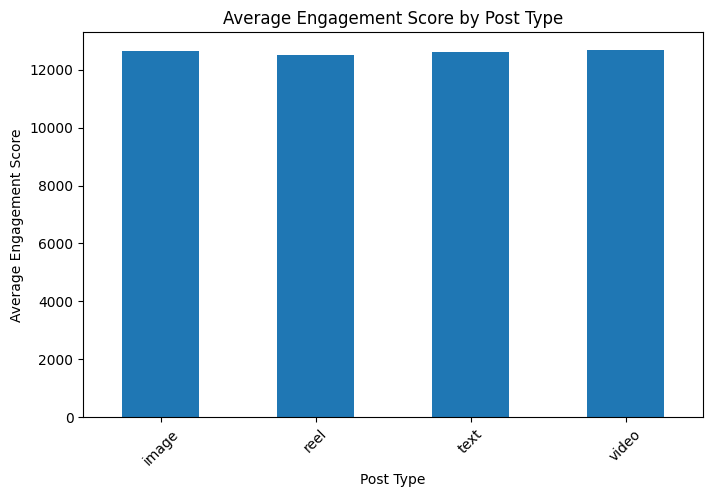

In [22]:
#----------Bar Chart----------

avg_engagement = df.groupby("post_type")["engagement_score"].mean()

plt.figure(figsize=(8,5))
avg_engagement.plot(kind="bar")

plt.title("Average Engagement Score by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Average Engagement Score")

plt.xticks(rotation=45)
plt.show()

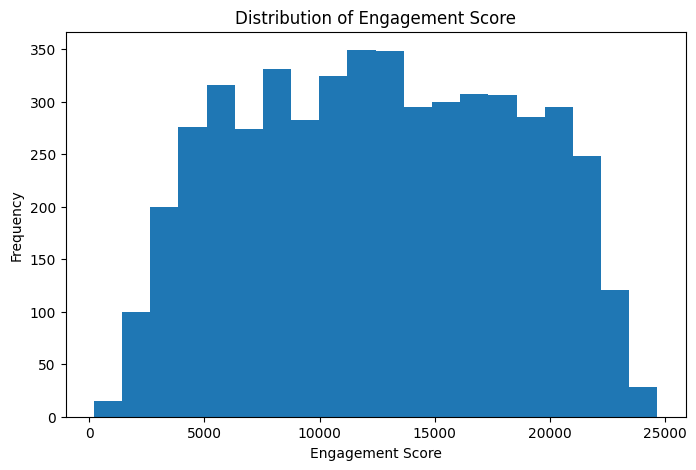

In [23]:
#----------Histogram----------

plt.figure(figsize=(8,5))

plt.hist(df["engagement_score"], bins=20)

plt.title("Distribution of Engagement Score")
plt.xlabel("Engagement Score")
plt.ylabel("Frequency")

plt.show()

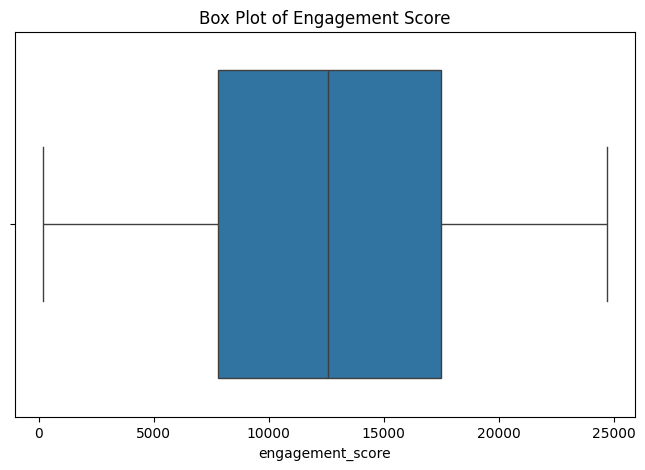

In [24]:
#----------Box Plot----------

plt.figure(figsize=(8,5))

sns.boxplot(x=df["engagement_score"])

plt.title("Box Plot of Engagement Score")

plt.show()

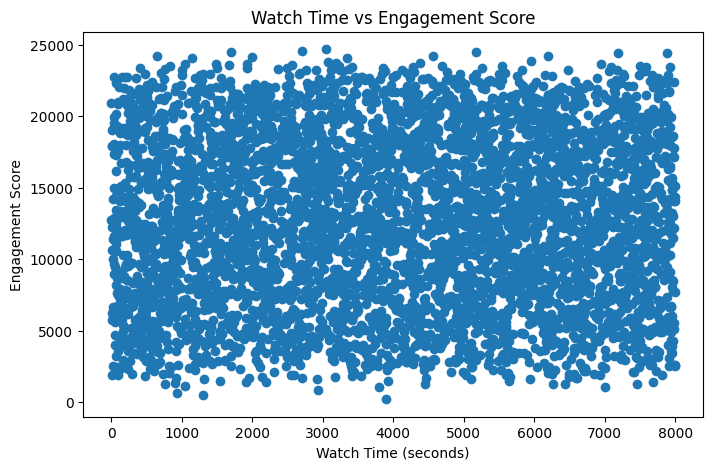

In [25]:
#----------Scatter Plot----------

plt.figure(figsize=(8,5))

plt.scatter(df["watch_time_sec"], df["engagement_score"])

plt.title("Watch Time vs Engagement Score")
plt.xlabel("Watch Time (seconds)")
plt.ylabel("Engagement Score")

plt.show()

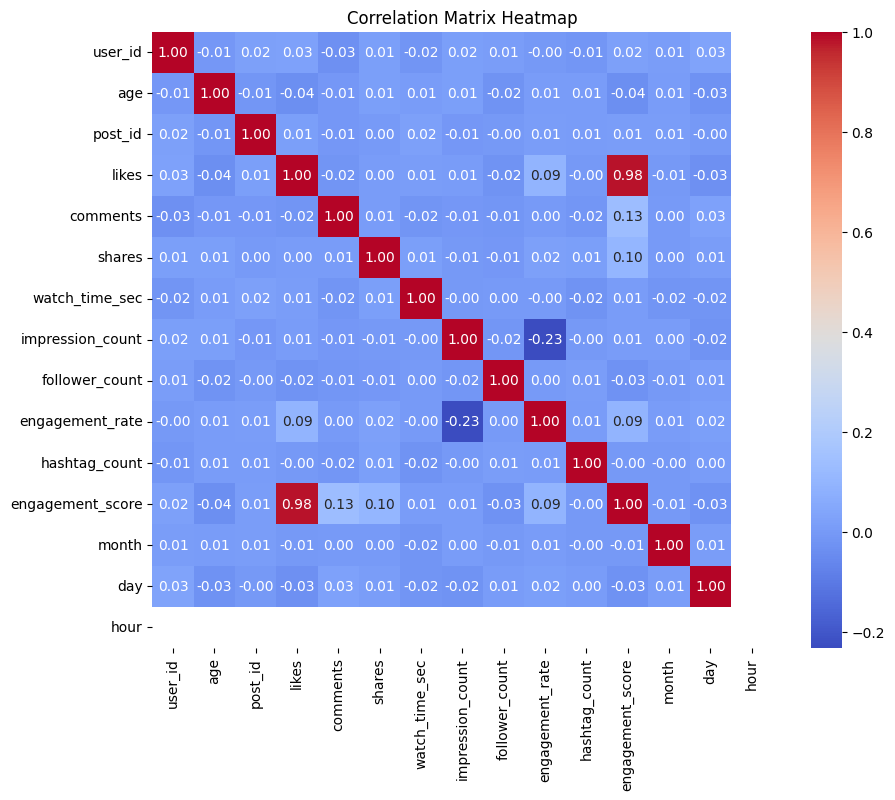

In [26]:
#----------Heatmap----------

plt.figure(figsize=(10, 8))

correlation_matrix = df.select_dtypes(include=["number"]).corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix Heatmap")

plt.show()

In [27]:
#----------Import Plotly----------

import plotly.express as px

In [28]:
#----------Interactive Bar Chart----------

fig = px.bar(
    df.groupby("post_type", as_index=False)["engagement_score"].mean(),
    x="post_type",
    y="engagement_score",
    title="Average Engagement Score by Post Type"
)

fig.show()